In [48]:
# Core data manipulation and numerical computing
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Machine Learning -- preprocessing & model selection
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_val_score, GridSearchCV, RandomizedSearchCV, learning_curve
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif

# Machine Learning -- classifiers
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
import xgboost as xgb

# Imbalanced-learn -- resampling
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek

# Evaluation metrics
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    f1_score, precision_score, recall_score, accuracy_score,
    precision_recall_fscore_support, balanced_accuracy_score
)

# Clustering (used in V-feature engineering)
from sklearn.cluster import KMeans

# Global settings
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('All libraries loaded successfully.')
print(f'Random seed: {RANDOM_STATE}')

All libraries loaded successfully.
Random seed: 42


In [49]:
import gdown
import os

files = {
    'train_transaction.csv': '19GXUOXz4Gk5Bgqomx8VpihcRjcG-OGck',
    'test_transaction.csv': '1F8GuFLyMe5qNHrAzt43IRyQdnrW0fgJq',
    'train_identity.csv': '1hjOEevs3_nllmOiMqbJFna8pypgA-rtl',
    'test_identity.csv': '1IXXbyDvhREkqqad2SBxSjS_pzPTk1eGD'
}

# Download files from Google Drive
for filename, file_id in files.items():
    if not os.path.exists(filename):
        print(f'Downloading {filename}...')
        gdown.download(f'https://drive.google.com/uc?id={file_id}', filename, quiet=False)
    else:
        print(f'{filename} already exists, skipping...')

# Load data
train_transaction = pd.read_csv('train_transaction.csv')
print(f'Train transaction shape: {train_transaction.shape}')

train_identity = pd.read_csv('train_identity.csv')
print(f'Train identity shape: {train_identity.shape}')

merge_train_df = train_transaction.merge(train_identity, on='TransactionID', how='left')
print(f'Merged dataset shape: {merge_train_df.shape}')

train_transaction.csv already exists, skipping...
test_transaction.csv already exists, skipping...
train_identity.csv already exists, skipping...
test_identity.csv already exists, skipping...
Train transaction shape: (590540, 394)
Train identity shape: (144233, 41)
Merged dataset shape: (590540, 434)


In [50]:
#Initial summary of dataset
fraudCount = merge_train_df['isFraud'].sum()
totalCount = len(merge_train_df)
fraudRate = merge_train_df['isFraud'].mean()

print(f"\nOverview summary of the dataset")
print(f'  Total transactions : {totalCount}')
print(f'  Total features     : {merge_train_df.shape[1]}')
print(f'  Fraud transactions : {fraudCount}')
print(f'  Fraud rate         : {fraudRate:.3%}')


Overview summary of the dataset
  Total transactions : 590540
  Total features     : 434
  Fraud transactions : 20663
  Fraud rate         : 3.499%


Missing value analysis:
Features with missing data > 95%: 9
Feature with mising data between 50% - 94%: 205
Feature with missing data < 50%: 200


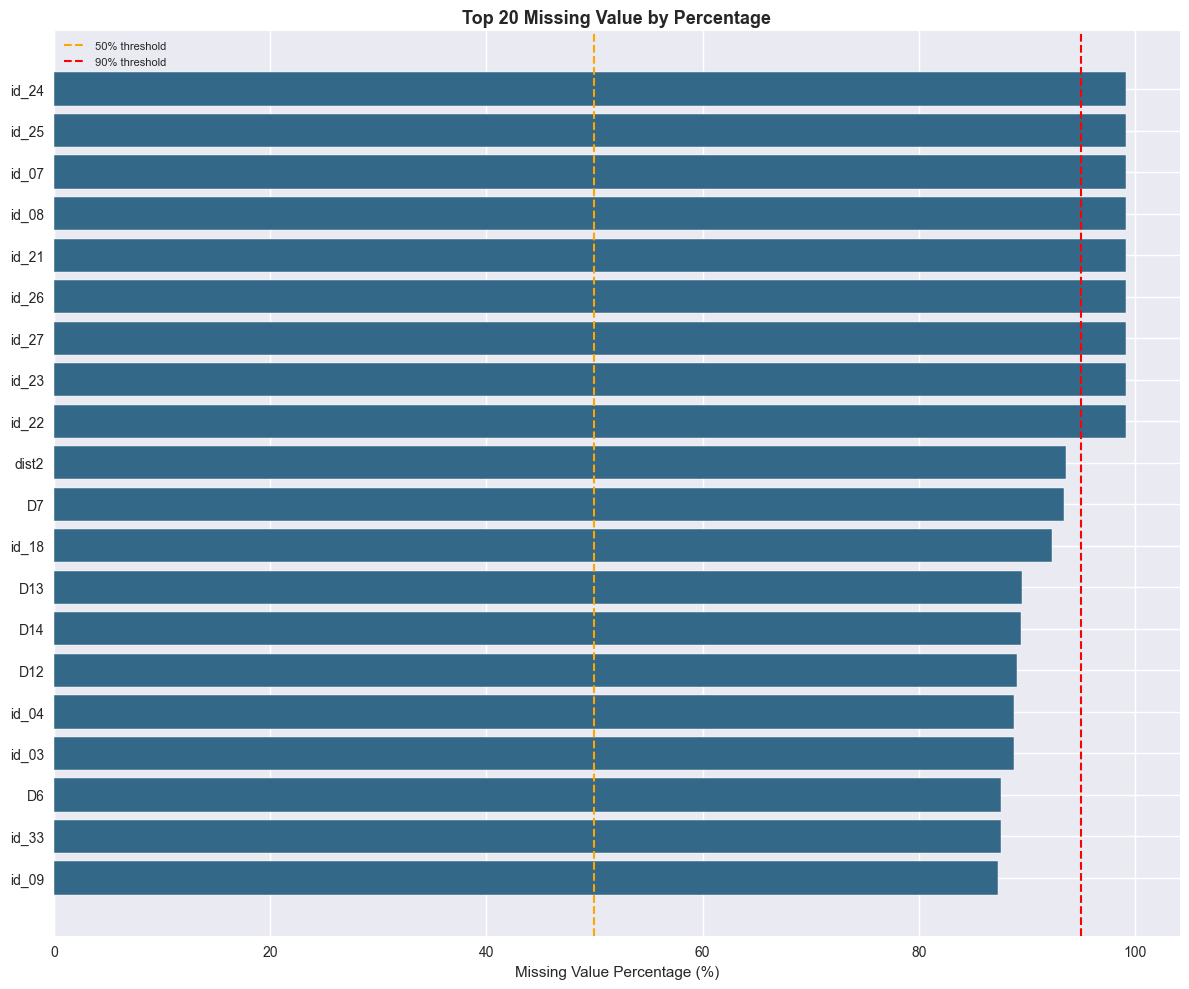

In [51]:
#Exploratory Data Analysis

#Missing Value Profiling
missing_count = merge_train_df.isnull().sum()
missing_percentage = (missing_count/len(merge_train_df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing Percentage': missing_percentage
}).sort_values('Missing Percentage', ascending=False)

print('Missing value analysis:')
print(f'Features with missing data > 95%: {(missing_percentage > 95).sum()}')
print(f'Feature with mising data between 50% - 94%: {((missing_percentage >= 50) & (missing_percentage < 95)).sum()}')
print(f'Feature with missing data < 50%: {((missing_percentage < 50) & (missing_percentage > 0)).sum()}')

# Visualise top  features by missingness
top_missing = missing_df[missing_df['Missing Count'] > 0].head(20)

fig, ax = plt.subplots(figsize=(12, 10))
ax.barh(
    top_missing.index[::-1],
    top_missing['Missing Percentage'][::-1],
    color = '#346888',
    edgecolor = 'white'
         )
ax.axvline(
    x=50,
    color = 'orange',
    linestyle = '--',
    linewidth = 1.5,
    label = '50% threshold'
)
ax.axvline(
    x=95,
    color = 'red',
    linestyle = '--',
    linewidth = 1.5,
    label = '90% threshold'
)
ax.set_xlabel('Missing Value Percentage (%)')
ax.set_title('Top 20 Missing Value by Percentage', fontweight='bold', fontsize=13)
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('Fig.1 [Top 20 Missing Value by Percentage].png', dpi=150, bbox_inches='tight') #Extract to image
plt.show()


Target Variable Distribution:
Not Fraud: 569877 (96.50%)
Fraud: 20663 (3.50%)
Imbalance Ratio: 27.6 : 1


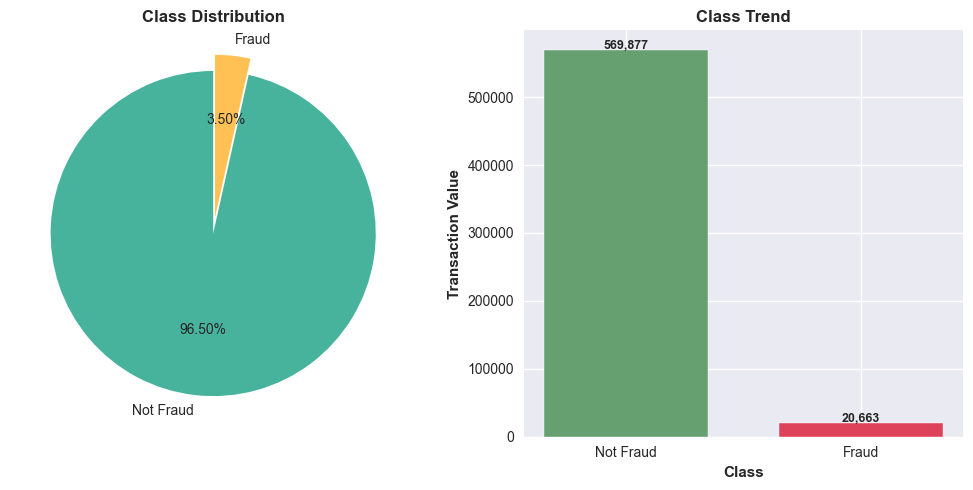

In [52]:
#Fraud & Non-Fraud Distribution

fraud_stats = merge_train_df['isFraud'].value_counts()
imbalance_ratio = fraud_stats[0] / fraud_stats[1]

print('Target Variable Distribution:')
print(f'Not Fraud: {fraud_stats[0]} ({fraud_stats[0]/len(merge_train_df)*100:.2f}%)')
print(f'Fraud: {fraud_stats[1]} ({fraud_stats[1]/len(merge_train_df)*100:.2f}%)')
print(f'Imbalance Ratio: {imbalance_ratio:.1f} : 1')

fig, axes = plt.subplots(1,2, figsize=(10, 5))

axes[0].pie(
    fraud_stats.values,
    labels=['Not Fraud', 'Fraud'],
    autopct = '%1.2f%%',
    startangle = 90,    
    colors = ['#47B39C', '#FFC154'],
    explode = (0, 0.1),
)
axes[0].set_title('Class Distribution', fontweight = 'bold')

axes[1].bar(
    ['Not Fraud', 'Fraud'],
    fraud_stats.values,
    color = ['#66a070', '#de425b'],
    edgecolor = 'white',
    width = 0.7
)
axes[1].set_title('Class Trend', fontweight = 'bold')
axes[1].set_ylabel('Transaction Value', fontweight = 'bold')
axes[1].set_xlabel('Class', fontweight = 'bold')

for i, v in enumerate(fraud_stats.values):
    axes[1].text(i, v + 500, f'{v:,}', ha='center', fontsize=9, fontweight = 'bold')

plt.tight_layout()
plt.savefig('Fig 2 [Class Distribution]', dpi=150, bbox_inches = 'tight')
plt.show()


Statistic of Transaction Amount by Fraud Label:
isFraud           0          1
count   569877.0000 20663.0000
mean       134.5100   149.2400
std        239.4000   232.2100
min          0.2500     0.2900
25%         43.9700    35.0400
50%         68.5000    75.0000
75%        120.0000   161.0000
max      31937.3900  5191.0000


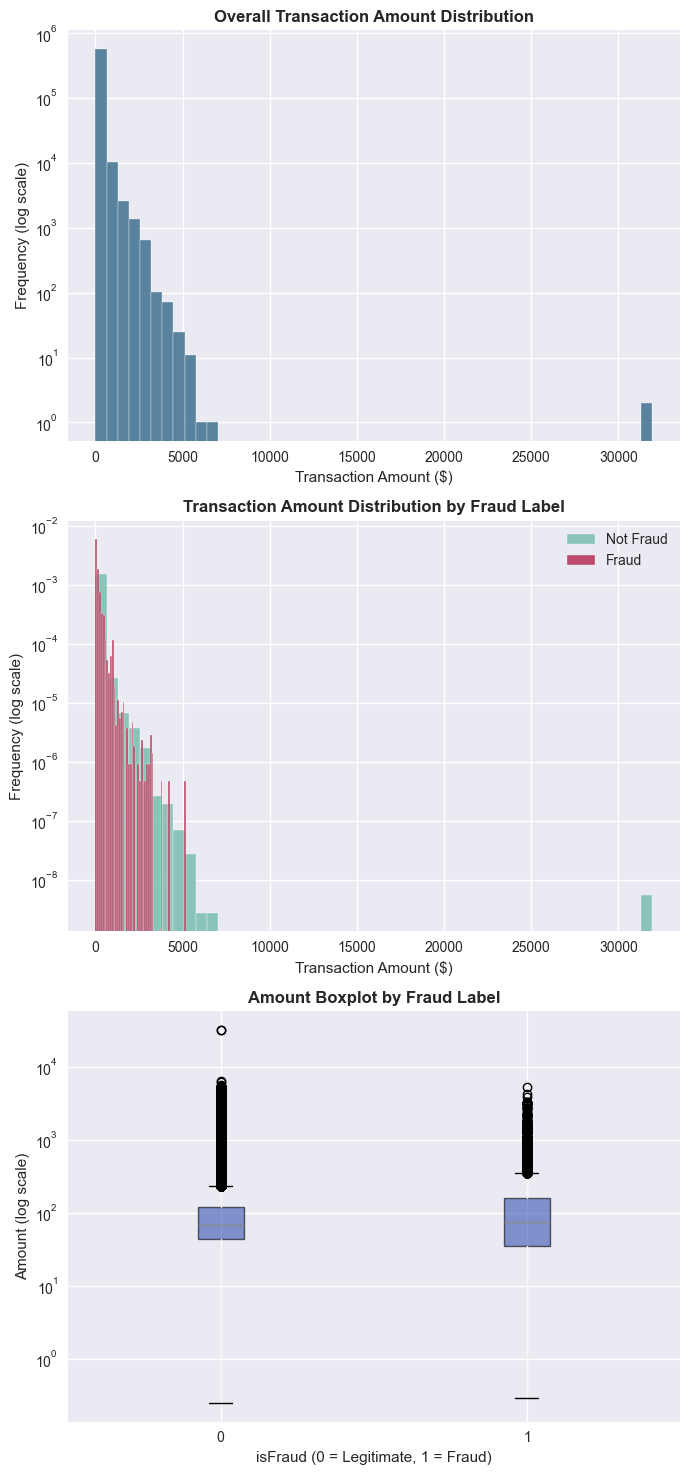

In [53]:
#Transaction Amount Analysis
amount_stats = merge_train_df.groupby('isFraud')['TransactionAmt'].describe().round(2)
print('Statistic of Transaction Amount by Fraud Label:')
print(amount_stats.T)

fig, axes = plt.subplots(3,1, figsize=(7, 15))

axes[0].hist(merge_train_df['TransactionAmt'], bins=50, color='#346888', edgecolor='white', alpha=0.8 )
axes[0].set_yscale('log')
axes[0].set_xlabel('Transaction Amount ($)')
axes[0].set_ylabel('Frequency (log scale)')
axes[0].set_title('Overall Transaction Amount Distribution', fontweight='bold')

fraud_amounts = merge_train_df[merge_train_df['isFraud'] == 1]['TransactionAmt']
normal_amounts = merge_train_df[merge_train_df['isFraud'] == 0]['TransactionAmt']
axes[1].hist(normal_amounts, bins = 50, color='#72BAA9', edgecolor='white', alpha=0.8, label='Not Fraud', density=True)
axes[1].hist(fraud_amounts, bins = 50, color='#AE2448', edgecolor='white', alpha=0.8, label='Fraud', density=True)
axes[1].set_yscale('log')
axes[1].set_xlabel('Transaction Amount ($)')
axes[1].set_ylabel('Frequency (log scale)')
axes[1].set_title('Transaction Amount Distribution by Fraud Label', fontweight='bold')
axes[1].legend()

merge_train_df.boxplot(
    column = 'TransactionAmt',
    by ='isFraud',
    ax = axes[2],
    patch_artist =True,
    boxprops = dict(
        facecolor = '#3852B4',
        alpha = 0.6
    )
)
axes[2].set_yscale('log')
axes[2].set_xlabel('isFraud (0 = Legitimate, 1 = Fraud)')
axes[2].set_ylabel('Amount (log scale)')
axes[2].set_title('Amount Boxplot by Fraud Label', fontweight='bold')
plt.suptitle('')

plt.tight_layout()
plt.savefig('Fig 3 [Transaction Amount Dsitribution].png', dpi=150, bbox_inches='tight')
plt.show()

Top 5 Riskiest Hours (by fraud rate):
   hour  transaction_count  fraud_count  fraud_rate
23.9842                  1            1      1.0000
13.5325                  1            1      1.0000
13.5269                  1            1      1.0000
13.5131                  1            1      1.0000
13.5058                  1            1      1.0000


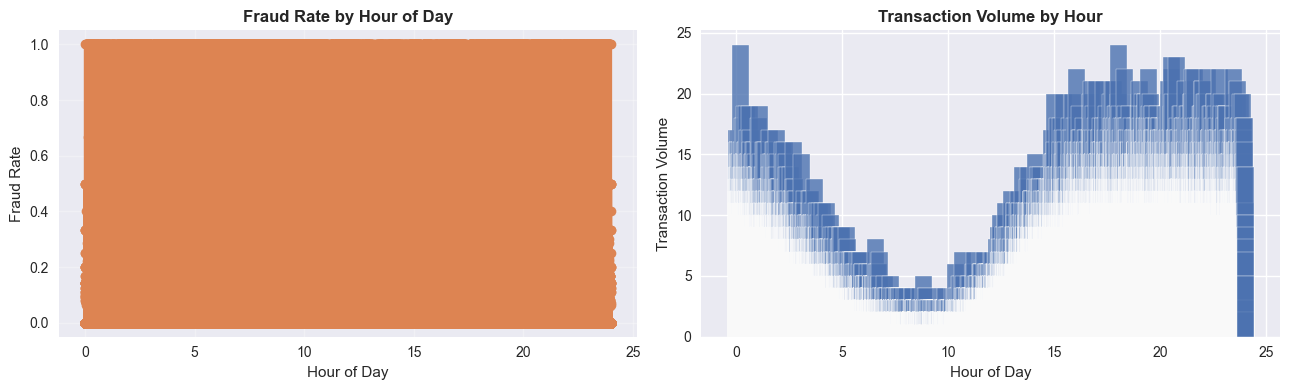

In [54]:
merge_train_df['hour']        = (merge_train_df['TransactionDT'] / 3600) % 24
merge_train_df['day']         = (merge_train_df['TransactionDT'] / 86400).astype(int)
merge_train_df['day_of_week'] = merge_train_df['day'] % 7

hourly_fraud = merge_train_df.groupby('hour')['isFraud'].agg(
    transaction_count='count',
    fraud_count='sum',
    fraud_rate='mean'
).reset_index()

print('Top 5 Riskiest Hours (by fraud rate):')
print(hourly_fraud.sort_values('fraud_rate', ascending=False).head(5).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(hourly_fraud['hour'], hourly_fraud['fraud_rate'],
             marker='o', color='#DD8452', linewidth=2)
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Fraud Rate')
axes[0].set_title('Fraud Rate by Hour of Day', fontweight='bold')
axes[0].grid(True, alpha=0.3)

daily_volume = merge_train_df.groupby('hour').size()
axes[1].bar(daily_volume.index, daily_volume.values,
            color='#4C72B0', alpha=0.8, edgecolor='white')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Transaction Volume')
axes[1].set_title('Transaction Volume by Hour', fontweight='bold')

plt.tight_layout()
plt.show()


CARD1 ANALYSIS
  Unique values       : 13,553
  Cards >= 10 txn     : 4,298
  Max fraud rate      : 1.000
  Average fraud rate  : 0.027

CARD2 ANALYSIS
  Unique values       : 500
  Cards >= 10 txn     : 500
  Max fraud rate      : 0.407
  Average fraud rate  : 0.030

CARD3 ANALYSIS
  Unique values       : 114
  Cards >= 10 txn     : 58
  Max fraud rate      : 0.389
  Average fraud rate  : 0.053

CARD4 ANALYSIS
  Unique values       : 4
  Cards >= 10 txn     : 4
  Max fraud rate      : 0.077
  Average fraud rate  : 0.044

CARD5 ANALYSIS
  Unique values       : 119
  Cards >= 10 txn     : 65
  Max fraud rate      : 0.333
  Average fraud rate  : 0.042

CARD6 ANALYSIS
  Unique values       : 4
  Cards >= 10 txn     : 4
  Max fraud rate      : 0.067
  Average fraud rate  : 0.023


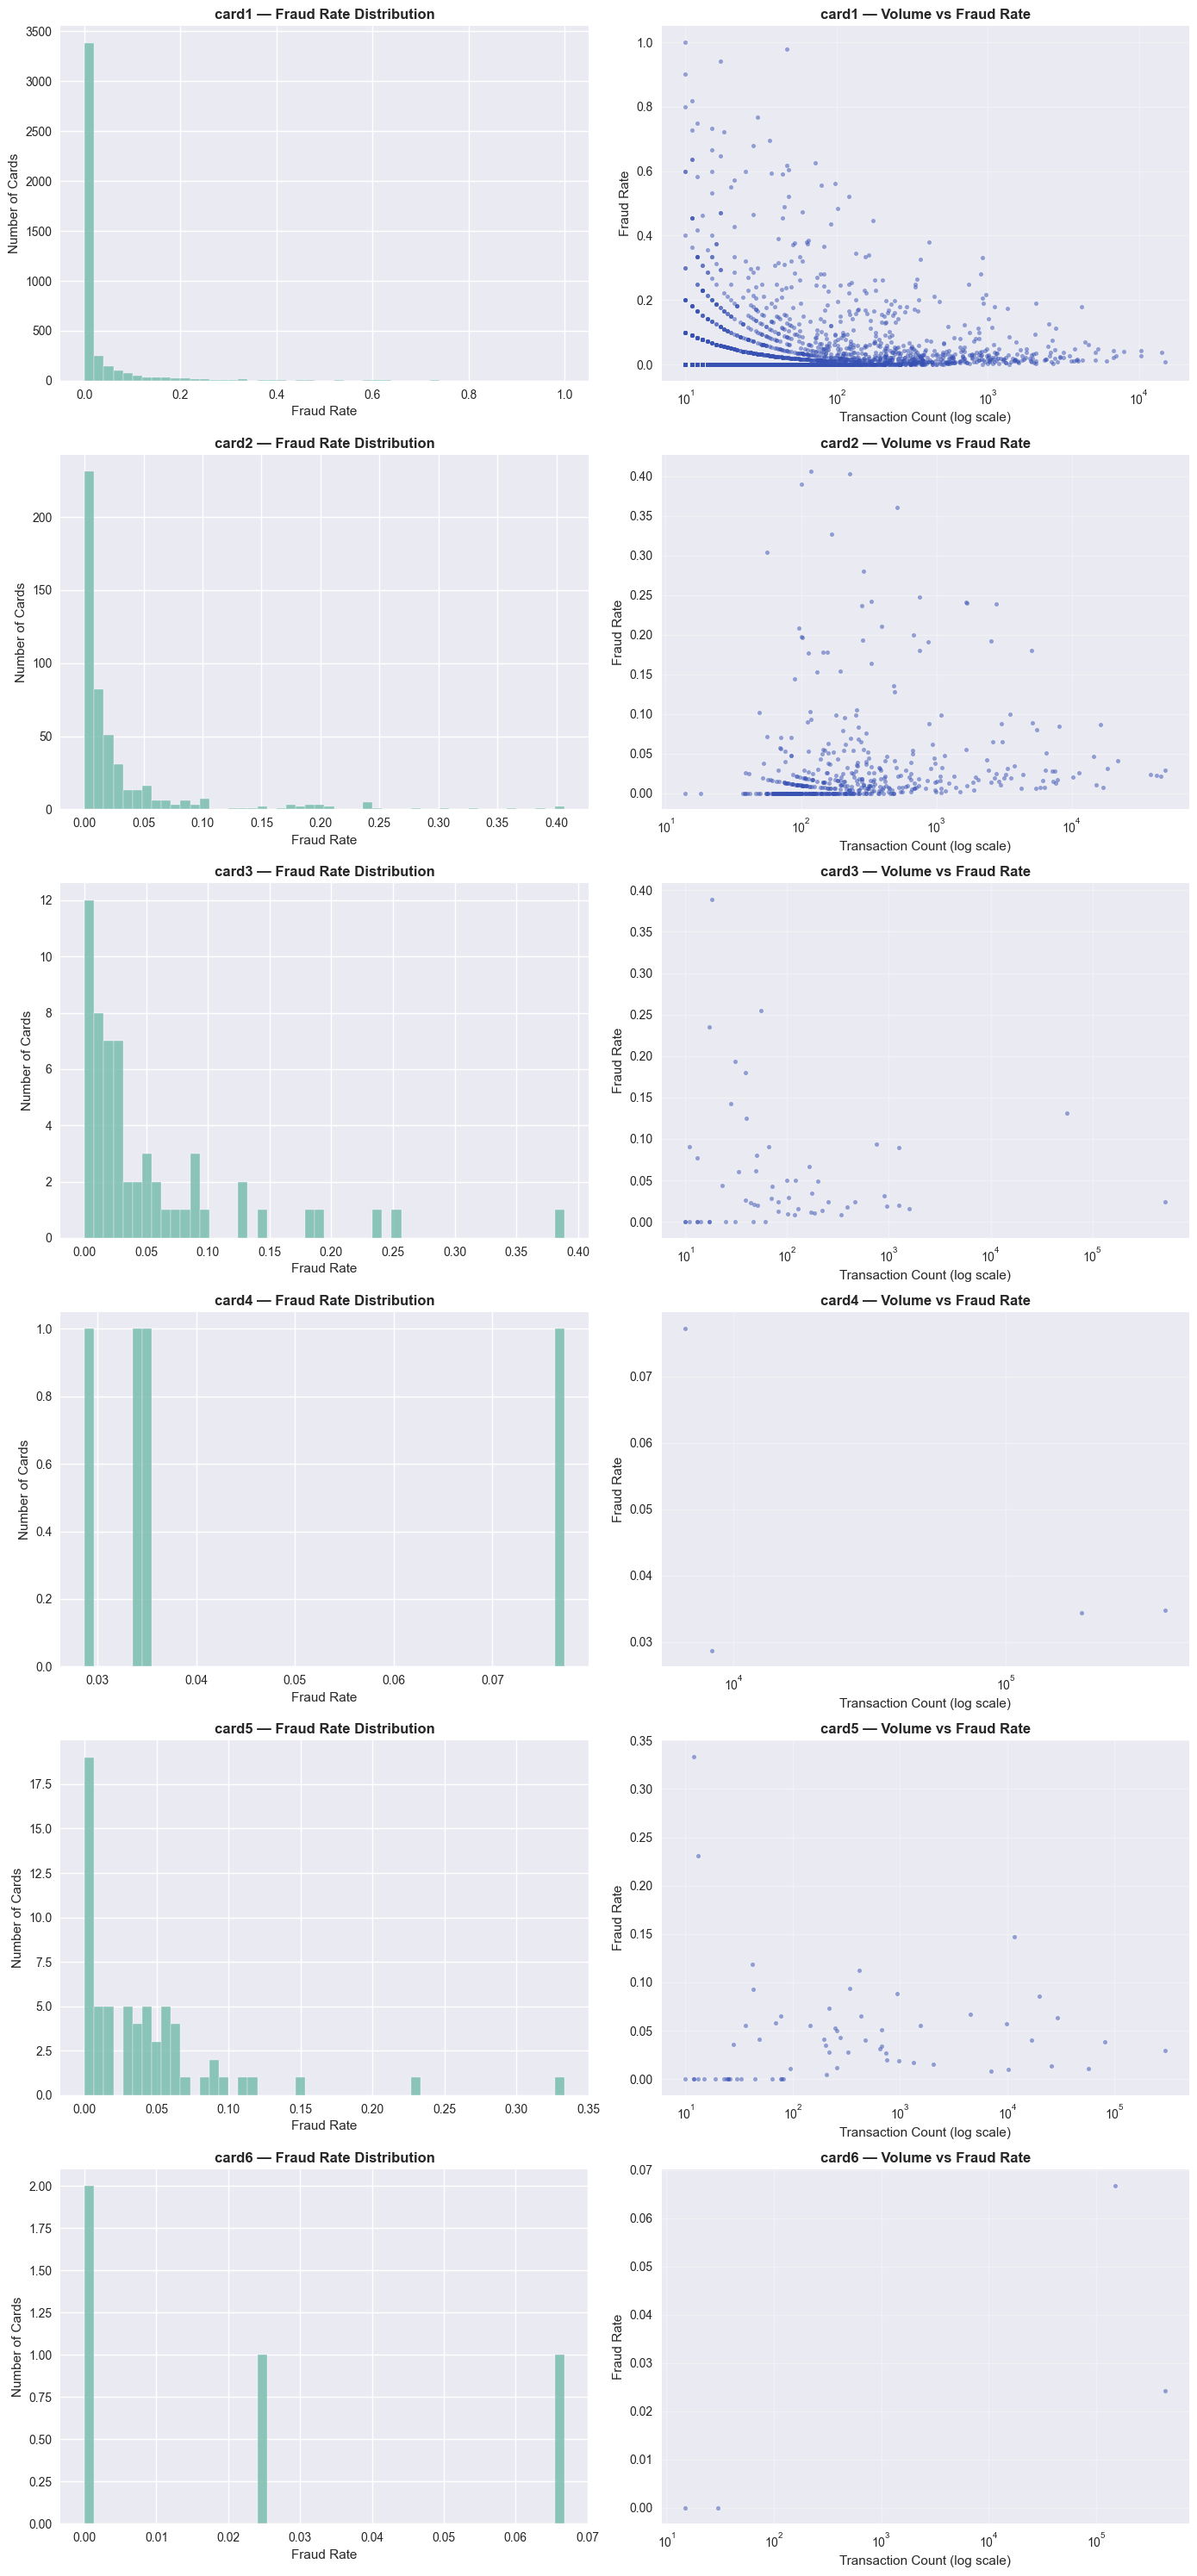

In [55]:
card_cols = [col for col in merge_train_df.columns if col.startswith('card')]

fig, axes = plt.subplots(len(card_cols), 2, figsize=(14, 5 * len(card_cols)))

for i, card in enumerate(card_cols):
    card_stats = (
        merge_train_df.groupby(card)['isFraud']
        .agg(count='count', fraud_sum='sum', fraud_rate='mean')
        .query('count >= 10')
        .sort_values('fraud_rate', ascending=False)
    )

    print(f'\n{card.upper()} ANALYSIS')
    print(f'  Unique values       : {merge_train_df[card].nunique():,}')
    print(f'  Cards >= 10 txn     : {len(card_stats):,}')
    print(f'  Max fraud rate      : {card_stats["fraud_rate"].max():.3f}')
    print(f'  Average fraud rate  : {card_stats["fraud_rate"].mean():.3f}')

    # Fraud rate distribution
    axes[i, 0].hist(card_stats['fraud_rate'], bins=50, color='#72BAA9', edgecolor='white', alpha=0.8)
    axes[i, 0].set_xlabel('Fraud Rate')
    axes[i, 0].set_ylabel('Number of Cards')
    axes[i, 0].set_title(f'{card} — Fraud Rate Distribution', fontweight='bold')

    # Volume vs fraud rate
    axes[i, 1].scatter(card_stats['count'], card_stats['fraud_rate'], alpha=0.5, s=10, color='#3852B4')
    axes[i, 1].set_xscale('log')
    axes[i, 1].set_xlabel('Transaction Count (log scale)')
    axes[i, 1].set_ylabel('Fraud Rate')
    axes[i, 1].set_title(f'{card} — Volume vs Fraud Rate', fontweight='bold')
    axes[i, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Top 10 Email Domains by Fraud Rate (>=100 transactions):
                 count  fraud_sum  fraud_rate
P_emaildomain                                
mail.com           559        106      0.1896
outlook.es         438         57      0.1301
aim.com            315         40      0.1270
outlook.com       5096        482      0.0946
hotmail.es         305         20      0.0656
live.com.mx        749         41      0.0547
hotmail.com      45250       2396      0.0530
gmail.com       228355       9943      0.0435
yahoo.fr           143          5      0.0350
embarqmail.com     260          9      0.0346


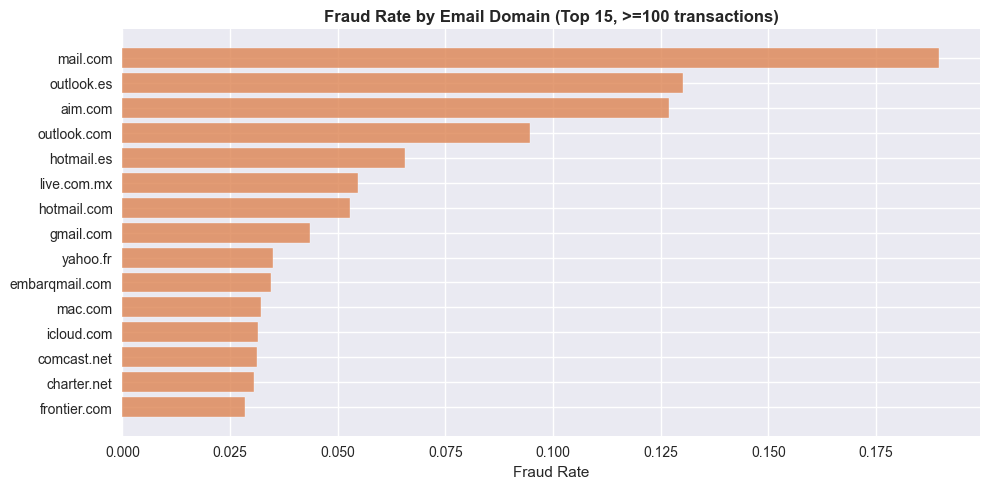

In [56]:
if 'P_emaildomain' in merge_train_df.columns:
    email_stats = (
        merge_train_df.groupby('P_emaildomain')['isFraud']
        .agg(count='count', fraud_sum='sum', fraud_rate='mean')
        .query('count >= 100')
        .sort_values('fraud_rate', ascending=False)
    )

    print('Top 10 Email Domains by Fraud Rate (>=100 transactions):')
    print(email_stats.head(10).to_string())

    fig, ax = plt.subplots(figsize=(10, 5))
    top_email = email_stats.head(15).sort_values('fraud_rate')
    ax.barh(top_email.index, top_email['fraud_rate'],
            color='#DD8452', alpha=0.8, edgecolor='white')
    ax.set_xlabel('Fraud Rate')
    ax.set_title('Fraud Rate by Email Domain (Top 15, >=100 transactions)', fontweight='bold')
    plt.tight_layout()
    plt.savefig('fig_06_email_domains.png', dpi=150, bbox_inches='tight')
    plt.show()

In [57]:
#Feature Engineeringg
df_feature = merge_train_df.copy()

In [58]:
# Log transformation (reduces right-skew)
df_feature['TransactionAmt_log']     = np.log1p(df_feature['TransactionAmt'])

# Decimal component (round numbers may indicate scripted fraud)
df_feature['TransactionAmt_decimal'] = df_feature['TransactionAmt'] - df_feature['TransactionAmt'].astype(int)

# Binned amount categories
df_feature['amount_category'] = pd.cut(
    df_feature['TransactionAmt'],
    bins=[0, 50, 200, 1000, 5000, float('inf')],
    labels=['very_small', 'small', 'medium', 'large', 'very_large']
)

# Square-root transformation
df_feature['TransactionAmt_sqrt'] = np.sqrt(df_feature['TransactionAmt'])

print('Amount features created: TransactionAmt_log, TransactionAmt_decimal, amount_category, TransactionAmt_sqrt')

Amount features created: TransactionAmt_log, TransactionAmt_decimal, amount_category, TransactionAmt_sqrt


In [59]:
# Hour-level features
df_feature['hour']     = (df_feature['TransactionDT'] / 3600) % 24
df_feature['hour_sin'] = np.sin(2 * np.pi * df_feature['hour'] / 24)
df_feature['hour_cos'] = np.cos(2 * np.pi * df_feature['hour'] / 24)

# Day-level features
df_feature['day']         = (df_feature['TransactionDT'] / 86400).astype(int)
df_feature['day_of_week'] = df_feature['day'] % 7
df_feature['day_sin']     = np.sin(2 * np.pi * df_feature['day_of_week'] / 7)
df_feature['day_cos']     = np.cos(2 * np.pi * df_feature['day_of_week'] / 7)

# Binary context flags
df_feature['is_weekend']        = (df_feature['day_of_week'] >= 5).astype(int)
df_feature['is_night']          = ((df_feature['hour'] >= 22) | (df_feature['hour'] <= 6)).astype(int)
df_feature['is_business_hours'] = ((df_feature['hour'] >= 9) & (df_feature['hour'] <= 17)).astype(int)

# Relative time (days since first observed transaction)
df_feature['days_since_start'] = (df_feature['TransactionDT'] - df_feature['TransactionDT'].min()) / 86400

print('Temporal features created: hour/day cyclical encodings, weekend/night/business flags, days_since_start')

Temporal features created: hour/day cyclical encodings, weekend/night/business flags, days_since_start


In [60]:
card_cols = [col for col in df_feature.columns if col.startswith('card')]

for card in card_cols:
    if card in df_feature.columns:
        # Usage frequency
        card_counts = df_feature[card].value_counts()
        df_feature[f'{card}_count'] = df_feature[card].map(card_counts)

        # Average spend per card
        card_avg_amount = df_feature.groupby(card)['TransactionAmt'].mean()
        df_feature[f'{card}_avg_amount'] = df_feature[card].map(card_avg_amount)
        df_feature[f'{card}_amount_vs_avg'] = df_feature['TransactionAmt'] / df_feature[f'{card}_avg_amount']

        # Historical fraud rate per card (target encoding)
        card_fraud_rate = df_feature.groupby(card)['isFraud'].mean()
        df_feature[f'{card}_fraud_rate'] = df_feature[card].map(card_fraud_rate)

        # Amount deviation from card's typical spend
        df_feature[f'{card}_amount_deviation'] = abs(df_feature['TransactionAmt'] - df_feature[f'{card}_avg_amount'])
        df_feature[f'{card}_amount_deviation_log'] = np.log1p(df_feature[f'{card}_amount_deviation'])

print(f'Card features created for: {card_cols}')
print(f'New features added: {len(card_cols) * 6}')

Card features created for: ['card1', 'card2', 'card3', 'card4', 'card5', 'card6']
New features added: 36


In [61]:
if 'P_emaildomain' in df_feature.columns:
    email_fraud_rate = df_feature.groupby('P_emaildomain')['isFraud'].mean()
    df_feature['email_fraud_rate'] = df_feature['P_emaildomain'].map(email_fraud_rate)
    df_feature['email_fraud_rate'].fillna(df_feature['isFraud'].mean(), inplace=True)

    common_emails                   = ['gmail.com', 'yahoo.com', 'hotmail.com', 'outlook.com', 'aol.com']
    df_feature['is_common_email']      = df_feature['P_emaildomain'].isin(common_emails).astype(int)
    df_feature['email_domain_length']  = df_feature['P_emaildomain'].str.len()

    print('Email features created: email_fraud_rate, is_common_email, email_domain_length')

Email features created: email_fraud_rate, is_common_email, email_domain_length


In [62]:
# V-features (Vesta engineered transaction validation signals)
v_cols = [col for col in df_feature.columns if col.startswith('V')]
if v_cols:
    v_cols_numeric = df_feature[v_cols].select_dtypes(include='number').columns.tolist()
    
    df_feature['v_features_count'] = df_feature[v_cols_numeric].count(axis=1)
    df_feature['v_features_mean']  = df_feature[v_cols_numeric].mean(axis=1)
    df_feature['v_features_std']   = df_feature[v_cols_numeric].std(axis=1)
    df_feature['v_features_min']   = df_feature[v_cols_numeric].min(axis=1)
    df_feature['v_features_max']   = df_feature[v_cols_numeric].max(axis=1)
    df_feature['v_features_range'] = df_feature['v_features_max'] - df_feature['v_features_min']

    if len(v_cols_numeric) >= 10:
        v_data_filled = df_feature[v_cols_numeric[:10]].fillna(0)
        kmeans = KMeans(n_clusters=5, random_state=RANDOM_STATE, n_init=10)
        df_feature['v_cluster'] = kmeans.fit_predict(v_data_filled)

    print(f'V-features aggregated ({len(v_cols_numeric)} numeric columns): count, mean, std, min, max, range, cluster')

# C-features (counting-type anonymised features)
c_cols = [col for col in df_feature.columns if col.startswith('C')]
if c_cols:
    c_cols_numeric = df_feature[c_cols].select_dtypes(include='number').columns.tolist()

    df_feature['c_features_count'] = df_feature[c_cols_numeric].count(axis=1)
    df_feature['c_features_sum'] = df_feature[c_cols_numeric].sum(axis=1)
    df_feature['c_features_mean'] = df_feature[c_cols_numeric].mean(axis=1)
    print(f'C-features aggregated ({len(c_cols_numeric)} numeric columns): count, sum, mean')

# D-features (timedelta-type anonymised features)
d_cols = [col for col in df_feature.columns if col.startswith('D')]
if d_cols:
    d_cols_numeric = df_feature[d_cols].select_dtypes(include='number').columns.tolist()

    df_feature['d_features_count'] = df_feature[d_cols_numeric].count(axis=1)
    df_feature['d_features_mean'] = df_feature[d_cols_numeric].mean(axis=1)
    df_feature['d_features_std'] = df_feature[d_cols_numeric].std(axis=1)
    print(f'D-features aggregated ({len(d_cols_numeric)} numeric columns): count, mean, std')

    df_feature.head()

V-features aggregated (339 numeric columns): count, mean, std, min, max, range, cluster
C-features aggregated (14 numeric columns): count, sum, mean
D-features aggregated (15 numeric columns): count, mean, std


In [66]:
# Amount x temporal interactions
df_feature['amount_hour_interaction']    = df_feature['TransactionAmt'] * df_feature['hour']
df_feature['amount_weekend_interaction'] = df_feature['TransactionAmt'] * df_feature['is_weekend']

# Address-level fraud rates and usage frequency
for addr_col in ['addr1', 'addr2']:
    if addr_col in df_feature.columns:
        addr_fraud_rate = df_feature.groupby(addr_col)['isFraud'].mean()
        df_feature[f'{addr_col}_fraud_rate'] = df_feature[addr_col].map(addr_fraud_rate)
        df_feature[f'{addr_col}_fraud_rate'].fillna(df_feature['isFraud'].mean(), inplace=True)
        addr_counts = df_feature[addr_col].value_counts()
        df_feature[f'{addr_col}_count'] = df_feature[addr_col].map(addr_counts)

# Device info features
if 'DeviceInfo' in df_feature.columns:
    device_fraud_rate = df_feature.groupby('DeviceInfo')['isFraud'].mean()
    df_feature['device_fraud_rate']  = df_feature['DeviceInfo'].map(device_fraud_rate)
    df_feature['device_fraud_rate'].fillna(df_feature['isFraud'].mean(), inplace=True)
    df_feature['device_info_length'] = df_feature['DeviceInfo'].str.len()

print(f'Feature engineering summary')
print(f'  Original features    : {merge_train_df.shape[1]}')
print(f'  After engineering    : {df_feature.shape[1]}')
print(f'  New features created : {df_feature.shape[1] - merge_train_df.shape[1]}')

Feature engineering summary
  Original features    : 437
  After engineering    : 509
  New features created : 72
